In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
from pathlib import Path

rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
    'pgf.preamble': '',
    "font.family": "serif",
    "font.serif": ["times"],
    "axes.unicode_minus": False
})
plt.rc('xtick', top=True, bottom=True, labelsize=30, direction='in')
plt.rc('ytick', left=True, right=True, labelsize=30, direction='in')
plt.rc('xtick.major', size=16, pad=12, width=2.5)
plt.rc('ytick.major', size=16, pad=12, width=2.5)
plt.rc('xtick.minor', size=8, width=1.5)
plt.rc('ytick.minor', size=8, width=1.5)
plt.rc('axes', titlesize=35, labelsize=30, titleweight='bold', titlepad=20)
plt.rc('figure', titlesize=35)
plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [38]:
df = pd.read_csv('../benchmark/benchmark.csv')

# ADD VIRTUAL ROWS FOR V6 higher params
v6k0 = df.query('(version in ["V6", "V0"]) & (test == "k0")')[
    ['date', 'seed', 'version', 'device', 'exetime', 'power']].rename(
    columns={'exetime': 'exetime_one', 'power': 'power_one'})
v8k0 = df.query('(version == "V8") & (test == "k0") & (val != 1)')
merged = v8k0.merge(v6k0, on=['date', 'seed', 'device'], how='right').rename(columns={'version_y': 'version'})
merged['exetime'] = merged['exetime_one'] * merged['val']
merged['power'] = merged['power_one'] * merged['val']
merged.drop(columns=['exetime_one', 'power_one', 'version_x'], inplace=True)
# merged
df = pd.concat([df, merged])

df['power_inst'] = df['power'] / (df['exetime'] * 2)
df['power_energy'] = df['power'] * 0.5 / 3600
df['exetime'] /= 60

df = df.sort_values(['device', 'date', 'seed', 'val', 'version']).copy().reset_index(drop=True)
df

,date,seed,test,val,version,device,exetime,power,power_inst,power_energy
0,20111116,72,k0,1,V0,A100,15.651023,201492.864,107.284181,27.985120
1,20111116,72,k0,1,V8,A100,0.186767,4211.259,187.901867,0.584897
2,20111116,72,k0,2,V0,A100,31.302046,402985.728,107.284181,55.970240
3,20111116,72,k0,2,V8,A100,0.322197,7782.444,201.285978,1.080895
4,20111116,72,k0,4,V0,A100,62.604093,805971.456,107.284181,111.940480
...,...,...,...,...,...,...,...,...,...,...
8059,20180929,861,part,4096,V8,RTX 3090,0.077508,3148.876,338.555325,0.437344
8060,20180929,861,part,8192,V8,RTX 3090,0.134855,5609.753,346.652267,0.779132
8061,20180929,861,part,16384,V8,RTX 3090,0.260402,10702.601,342.503044,1.486472
8062,20180929,861,part,32768,V8,RTX 3090,0.514563,21156.359,342.626939,2.938383


In [39]:
df['date'].unique()

array([20111116, 20140917, 20150907, 20160827, 20170623, 20180929])

In [40]:
def set_axis_fine_grid(ax, axis='both'):
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='grey', axis=axis)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='darkgrey', axis=axis)


def make_pair_panel(sharey=True):
    fig, axs = plt.subplots(1, 2, figsize=(20, 10), tight_layout=True, sharey=sharey)
    ax1, ax2 = axs.flatten()
    for ax in (ax1, ax2):
        ax.set_xscale('log')
        ax.set_yscale('log')
        set_axis_fine_grid(ax)
    return fig, ax1, ax2


def make_figure_legend(fig, axs, title, map_handles=None, map_labels=None):
    ax1_handles, ax1_labels = axs[0].get_legend_handles_labels()
    for ax in axs[1:]:
        assert len(ax1_handles) == len(ax.get_legend_handles_labels()[0]) and len(ax1_labels) == len(
            ax.get_legend_handles_labels()[1])

    nrows = 2 if len(ax1_handles) > 8 else 1
    ncols = int(np.ceil(len(ax1_handles) / nrows))

    if map_handles is not None:
        ax1_handles = list(map(map_handles, ax1_handles))
    if map_labels is not None:
        ax1_labels = list(map(map_labels, ax1_labels))

    leg = fig.legend(
        handles=ax1_handles,
        labels=ax1_labels,
        title=title,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.16 if nrows > 1 else -0.11),
        ncol=ncols,
        handlelength=2,
        markerscale=2,
    )
    for line in leg.get_lines():
        line.set_linewidth(3)

    for ax in axs:
        ax.legend().remove()

    return leg


def format_int_to_date(date):
    date = str(date)
    return f'{date[:4]}-{date[4:6]}-{date[6:]}'

def save_plot(name):
    plt.savefig(Path().resolve().parent / 'data' / 'pubblications' / f'{name}.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(Path().resolve().parent / 'data' / 'pubblications' / f'{name}.png', bbox_inches='tight', pad_inches=0.1)

In [41]:
def plot_scale_vs_time_per_gpu(version, date):
    df_ = df.query(f'(version == "{version}") & (date == {date})')
    fig, ax1, ax2 = make_pair_panel()
    fig.suptitle(f'Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (period from {format_int_to_date(date)})',
                 y=1)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('ci', 100),
        ax=ax1,
    )
    ax1.set(title='Particles Sweep', xlabel=r'\# of quasiparticles', ylabel='runtime (min)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='exetime',
        hue='device',
        marker='o',
        errorbar=('ci', 100),
        ax=ax2,
    )
    ax2.set(title='Parametrizations Sweep ($k_0$)', xlabel=r'\# of parametrizations', ylabel='runtime (min)')

    make_figure_legend(fig, (ax1, ax2), 'GPU')

    return fig, ax1, ax2

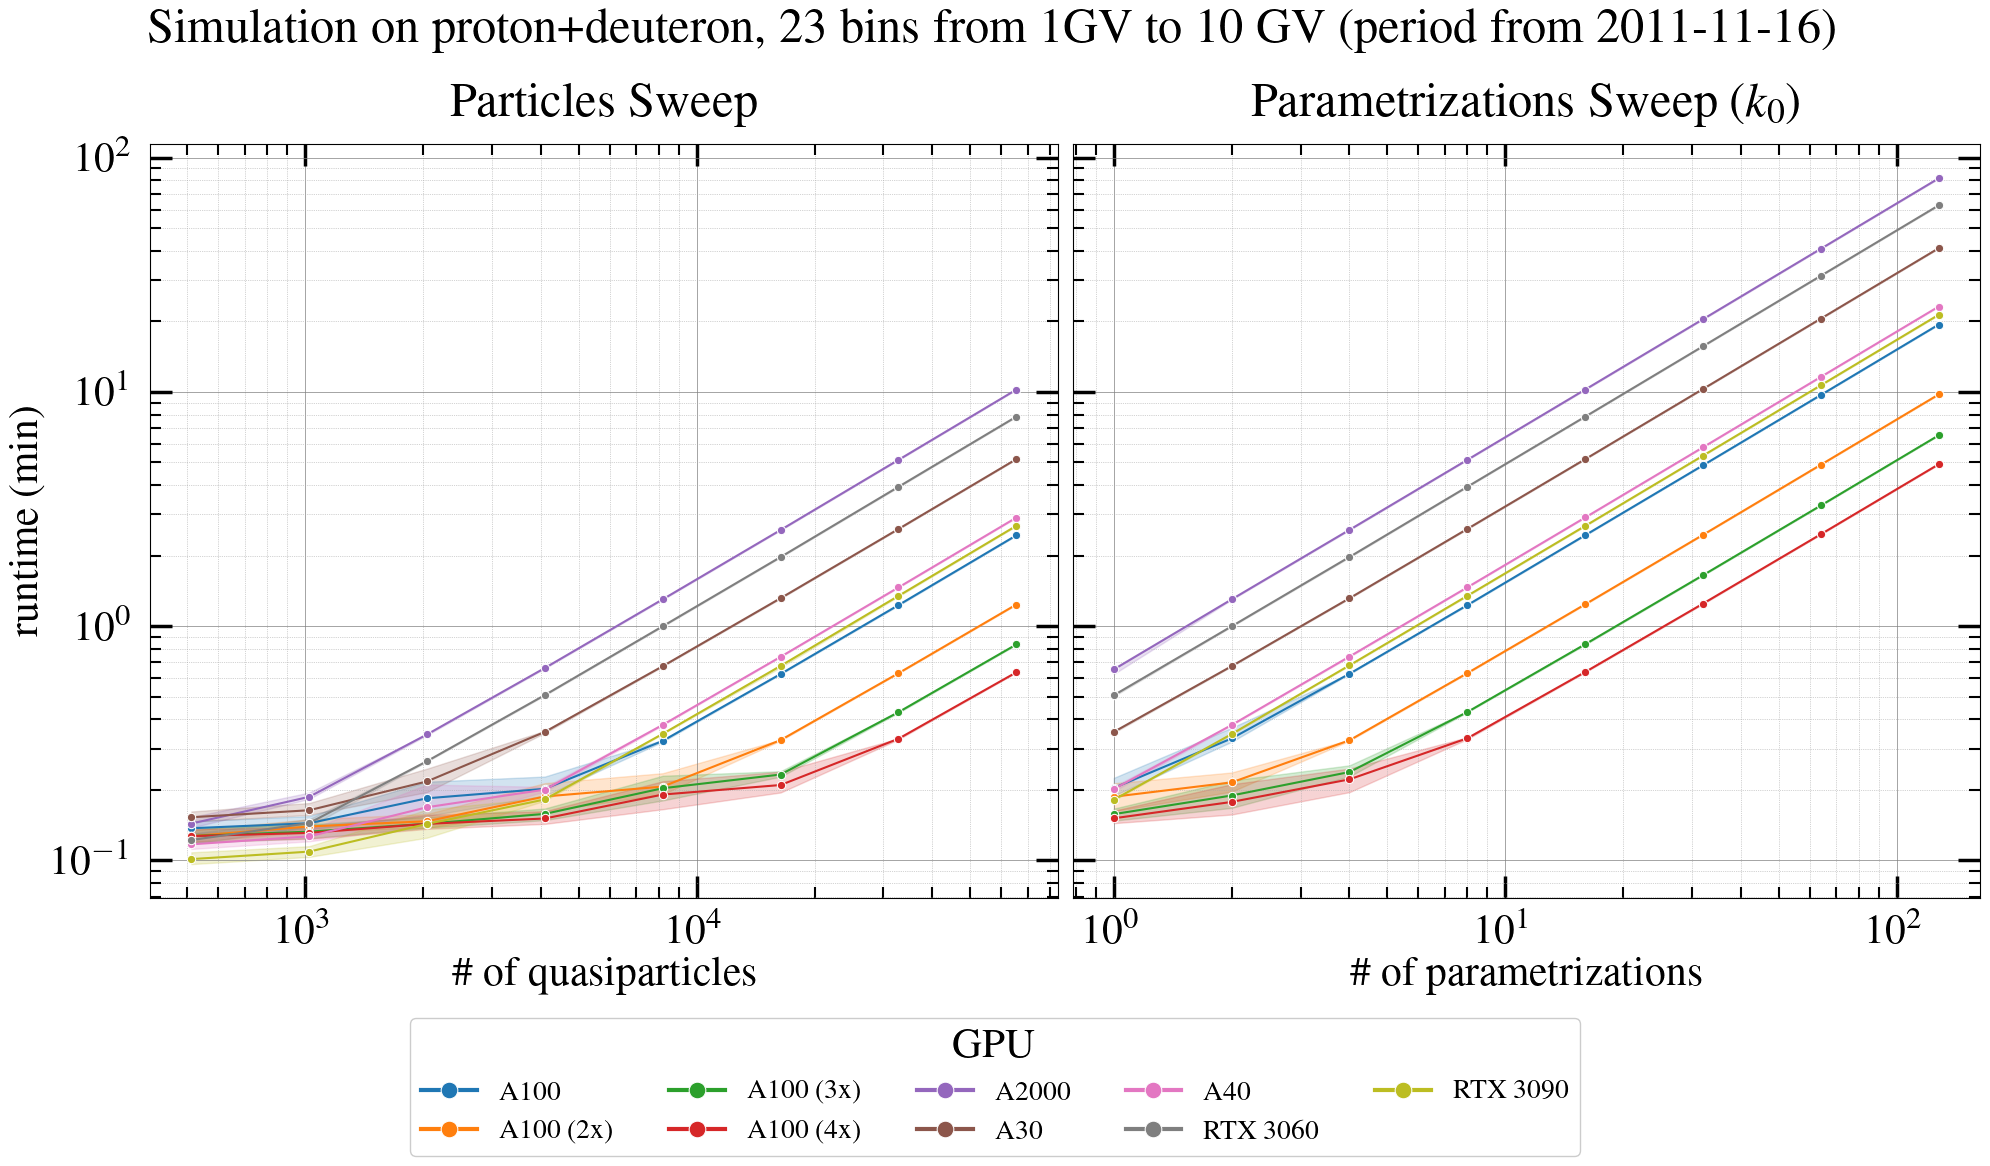

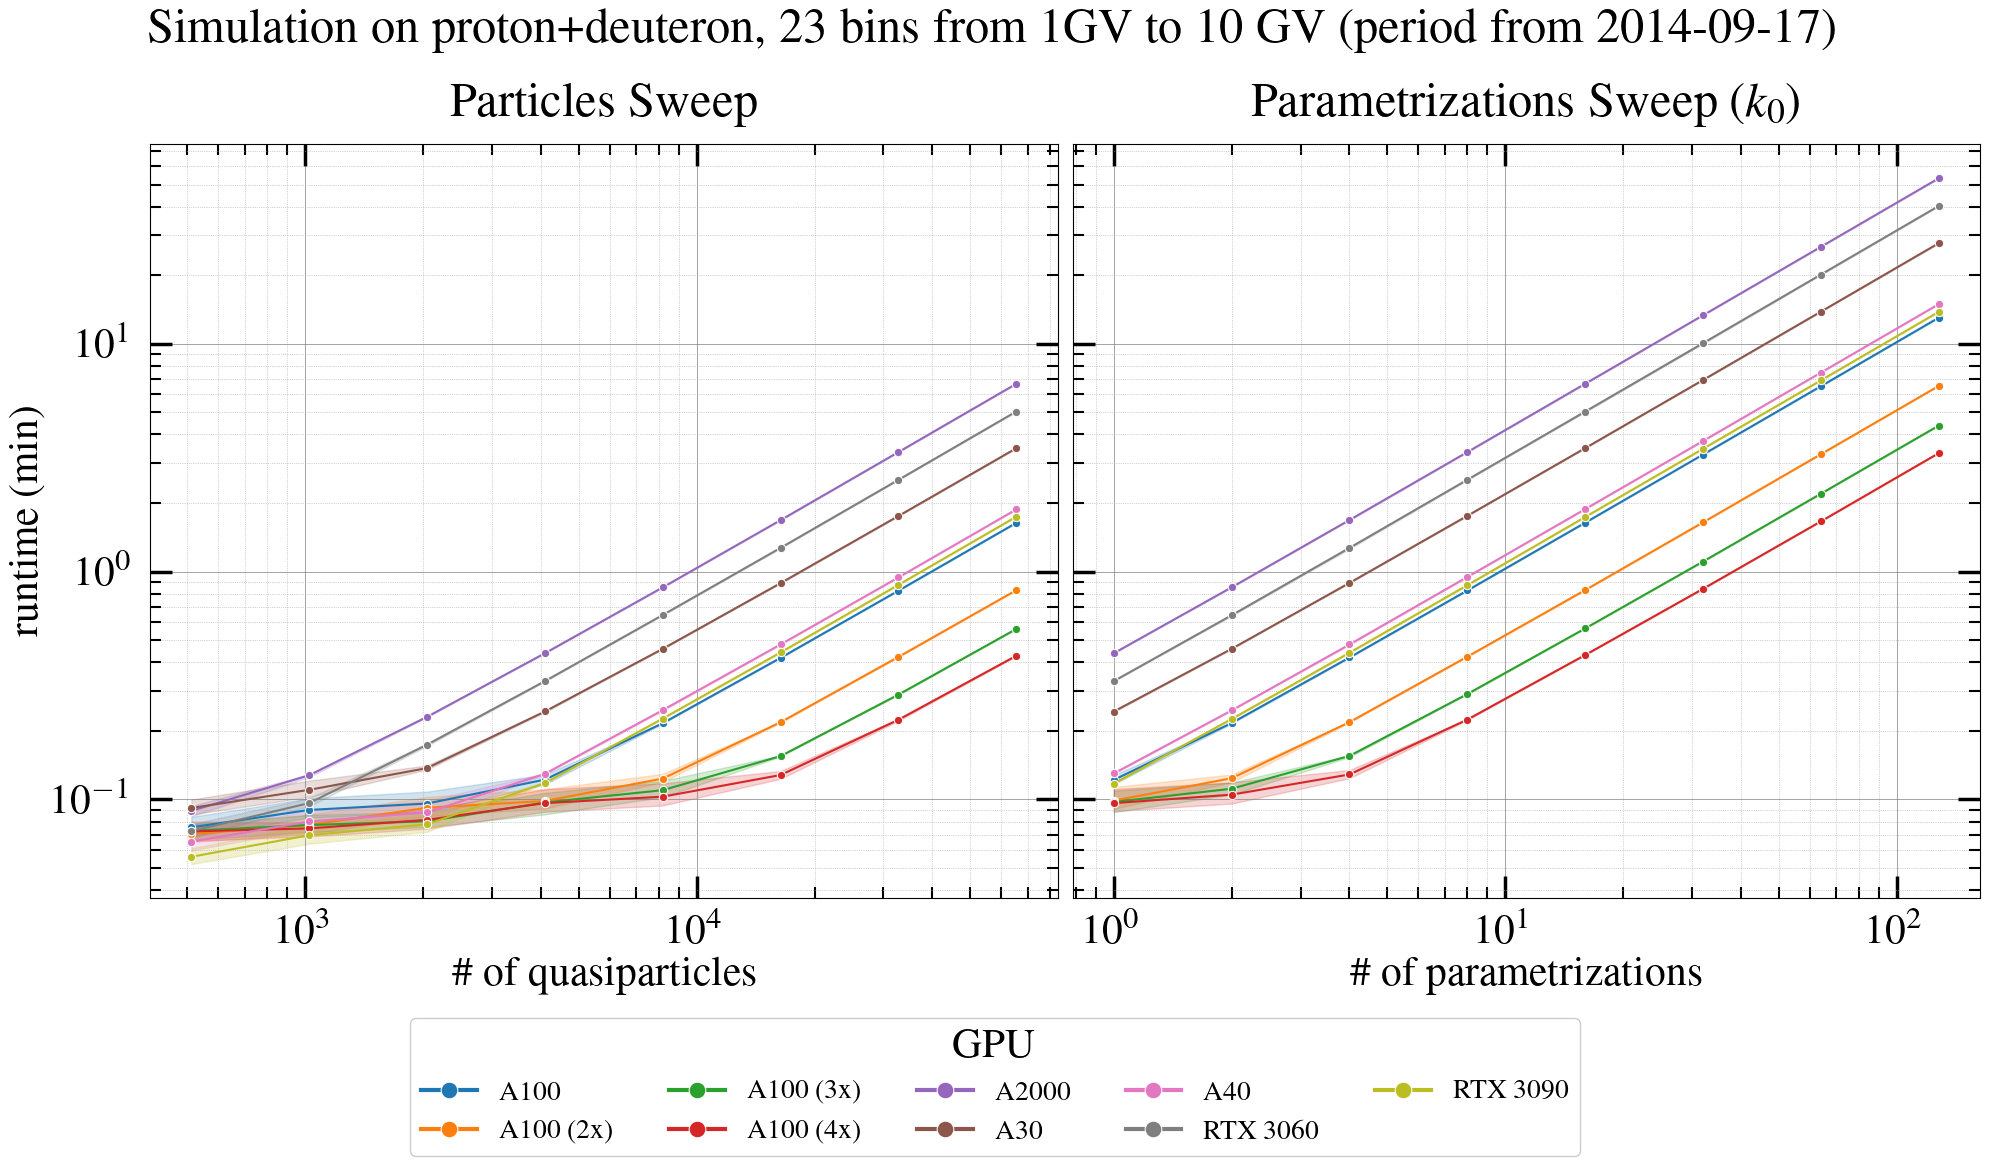

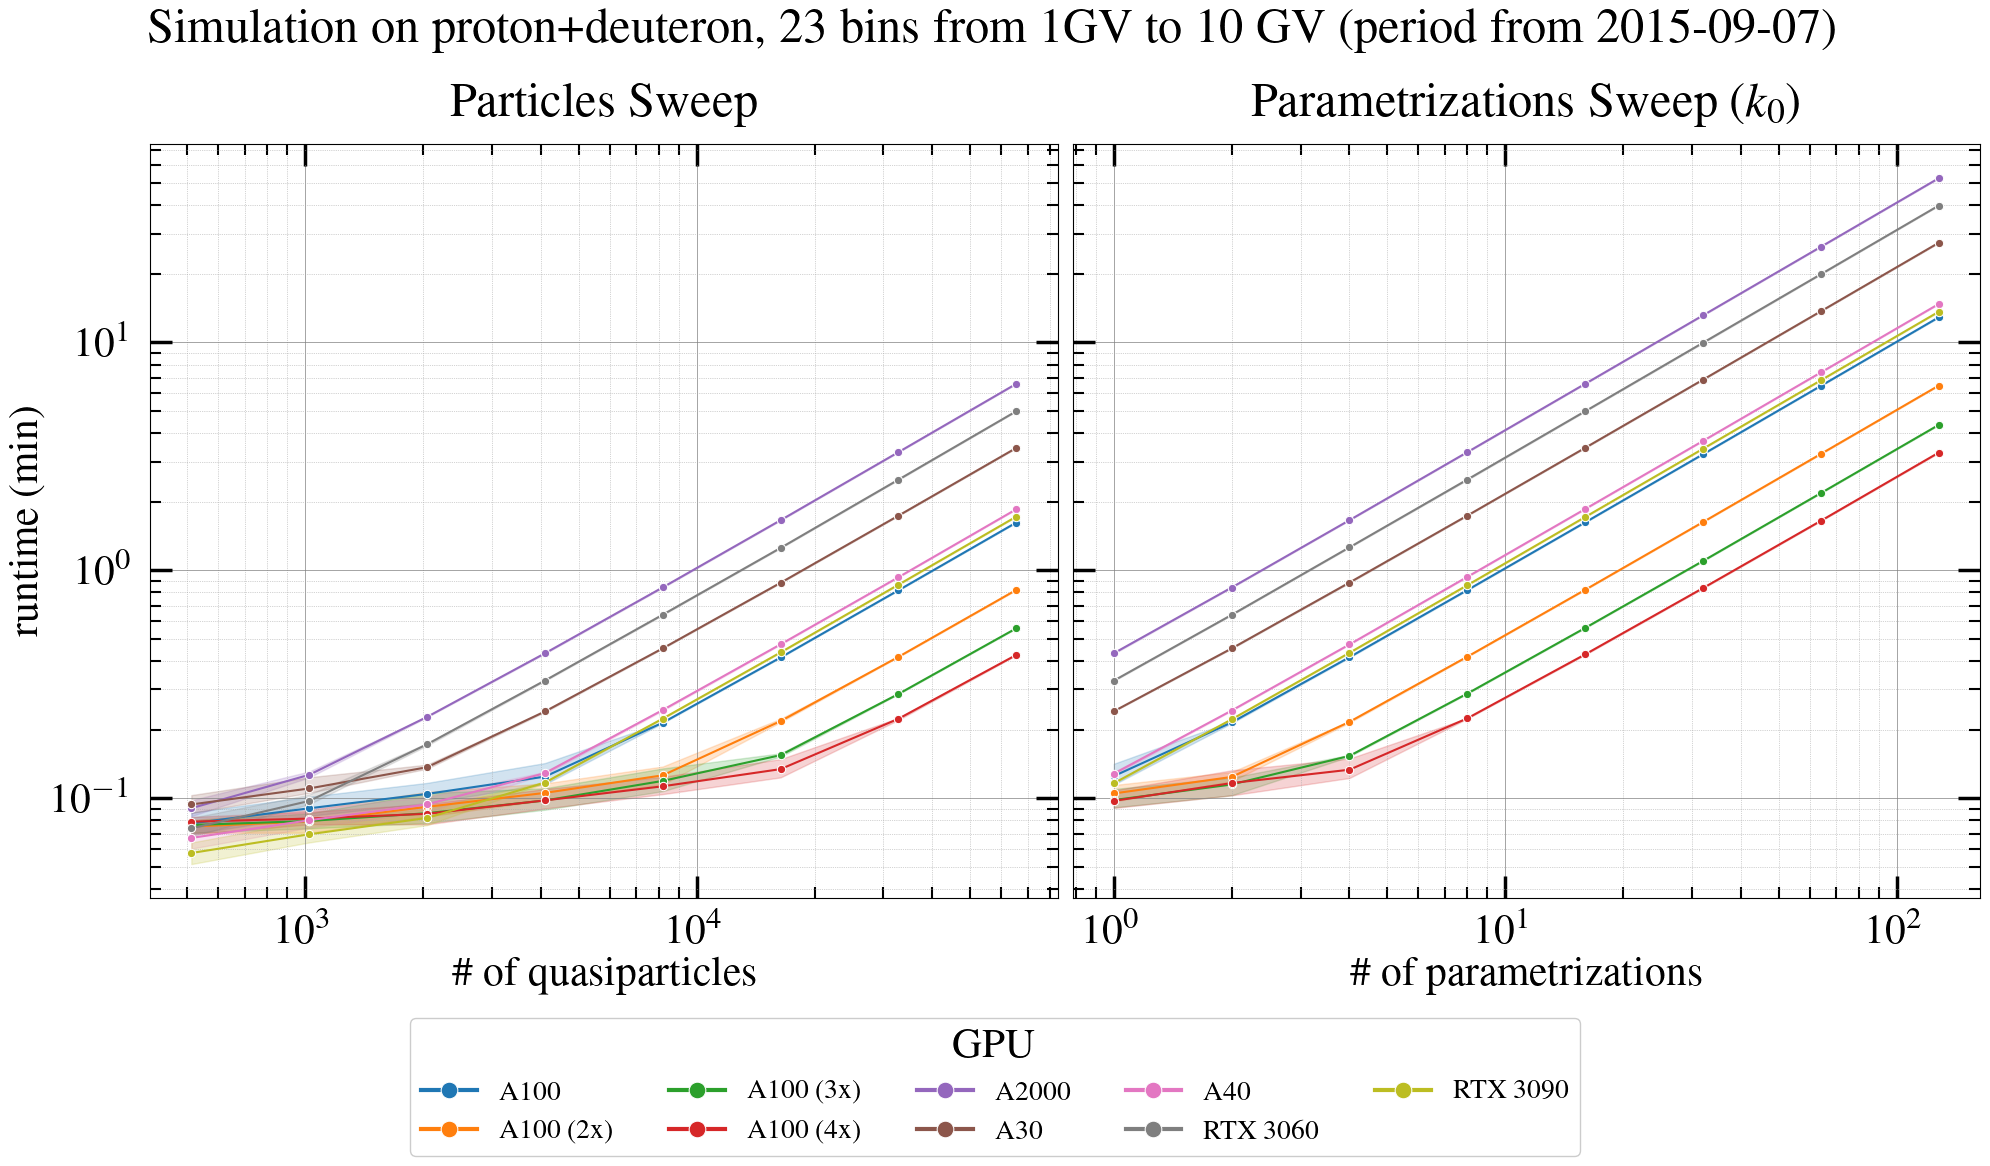

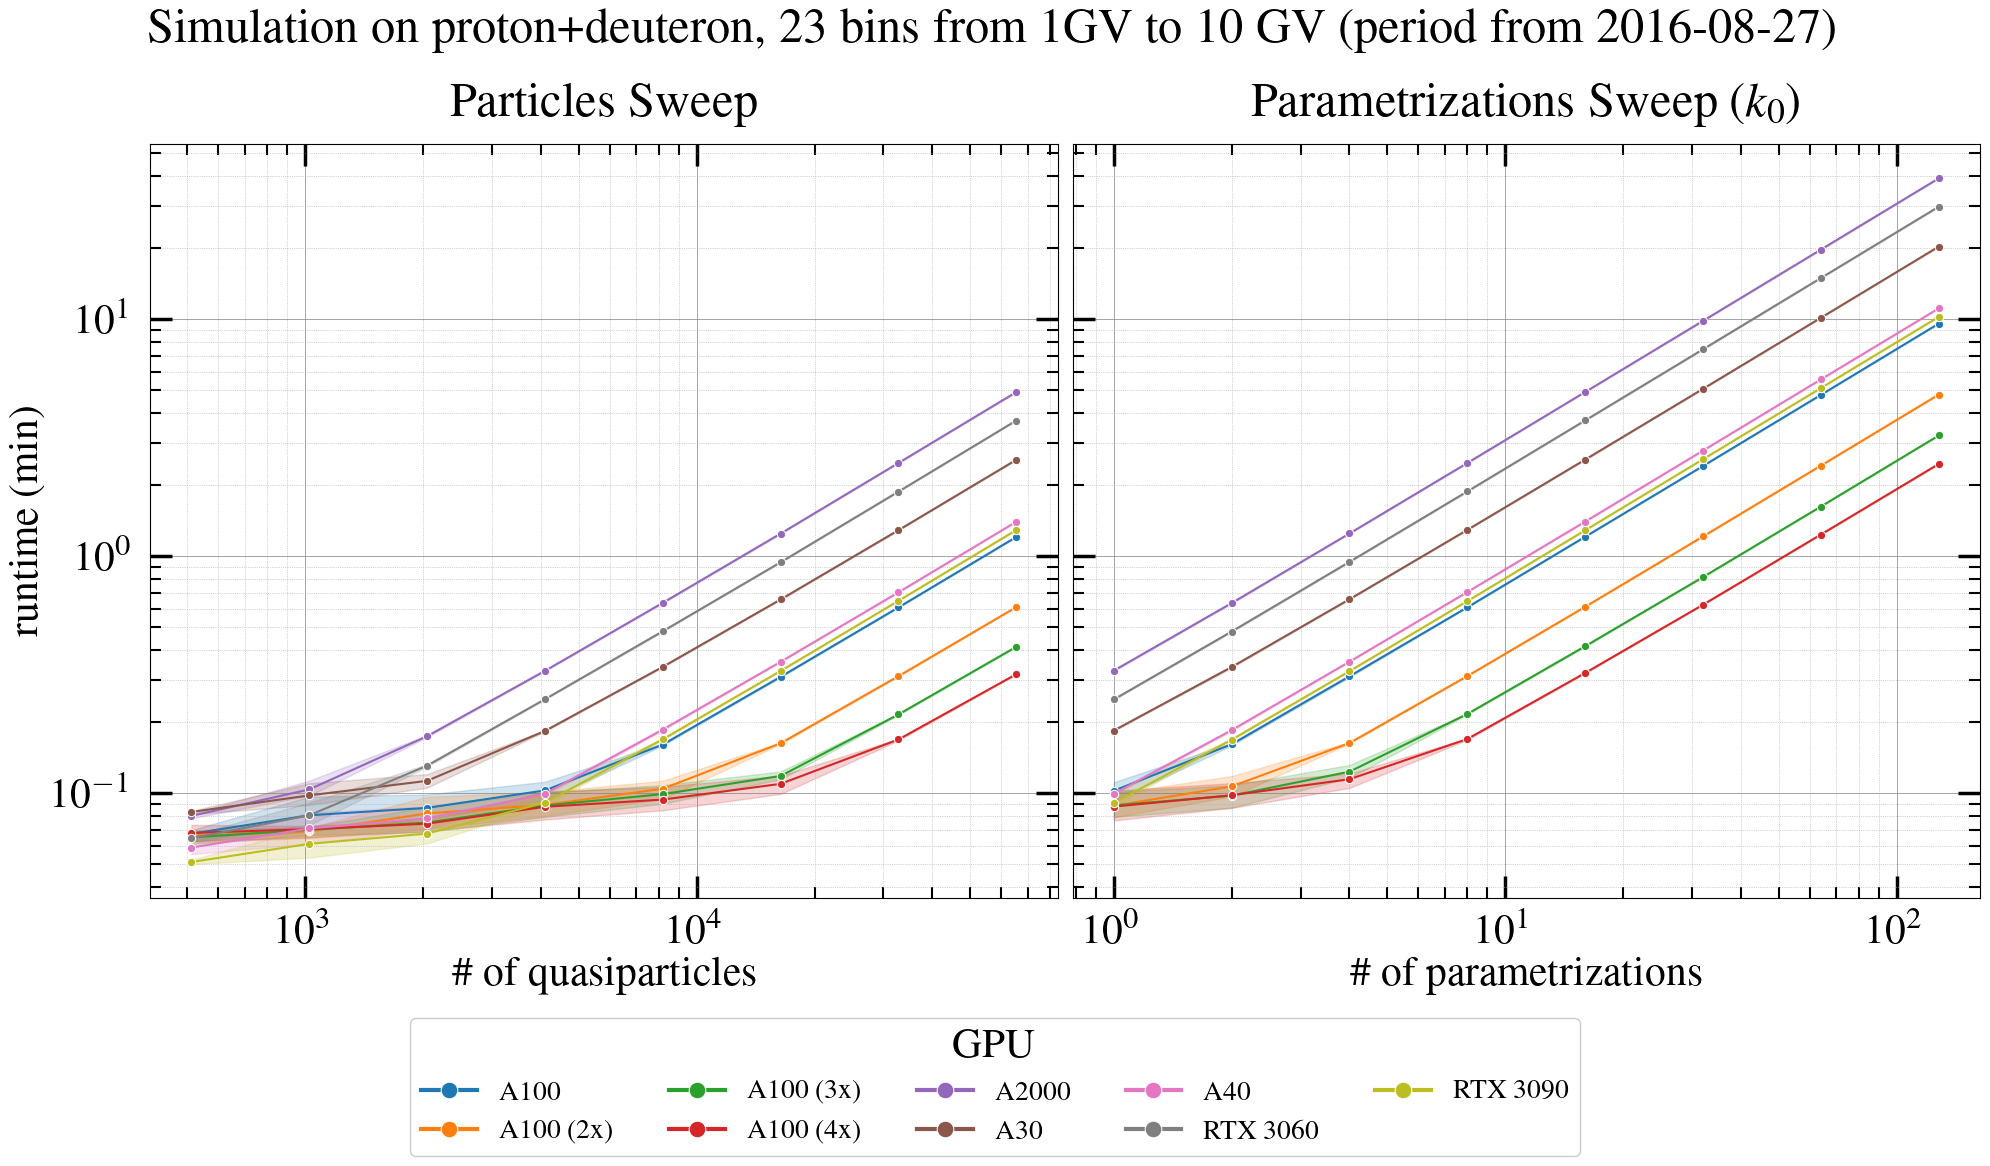

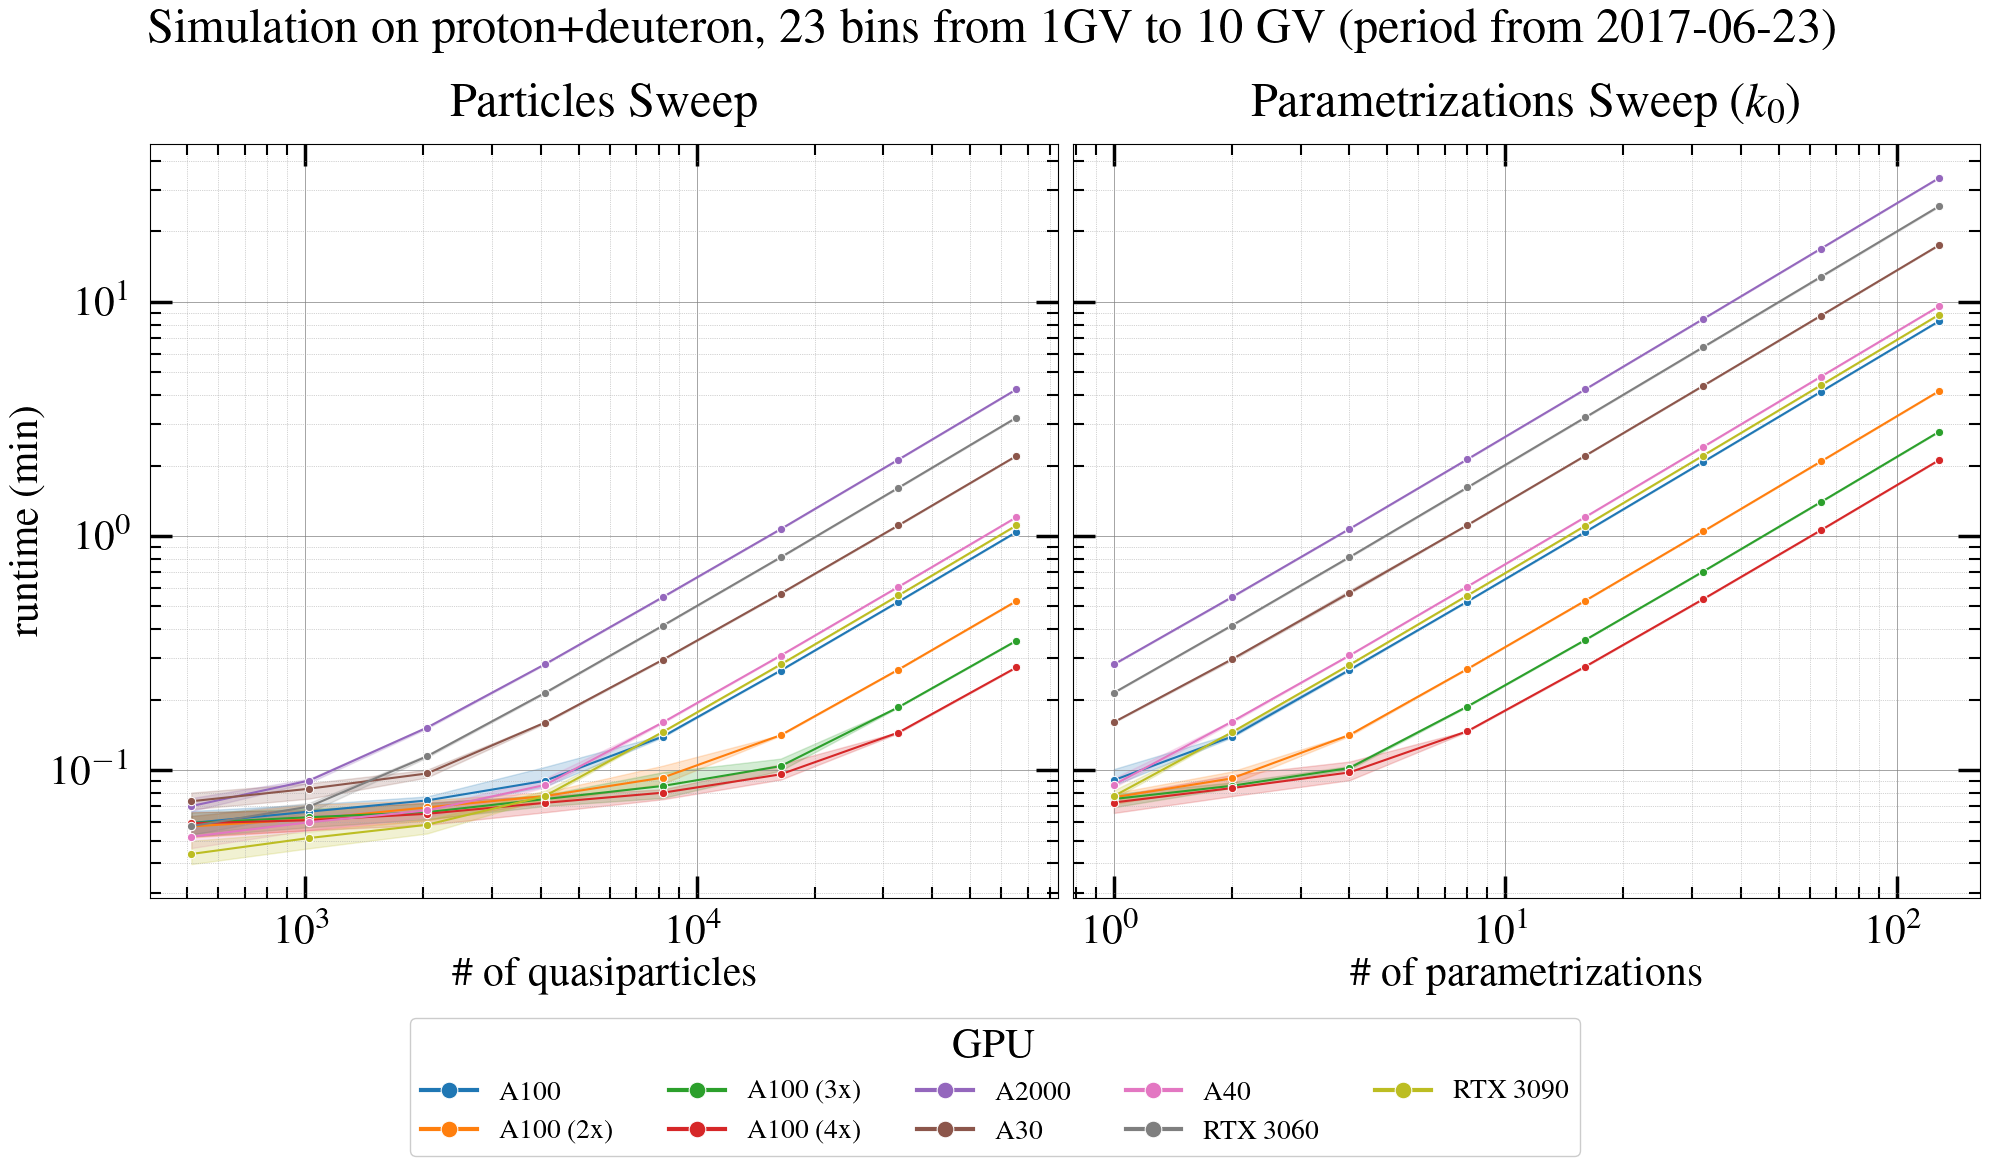

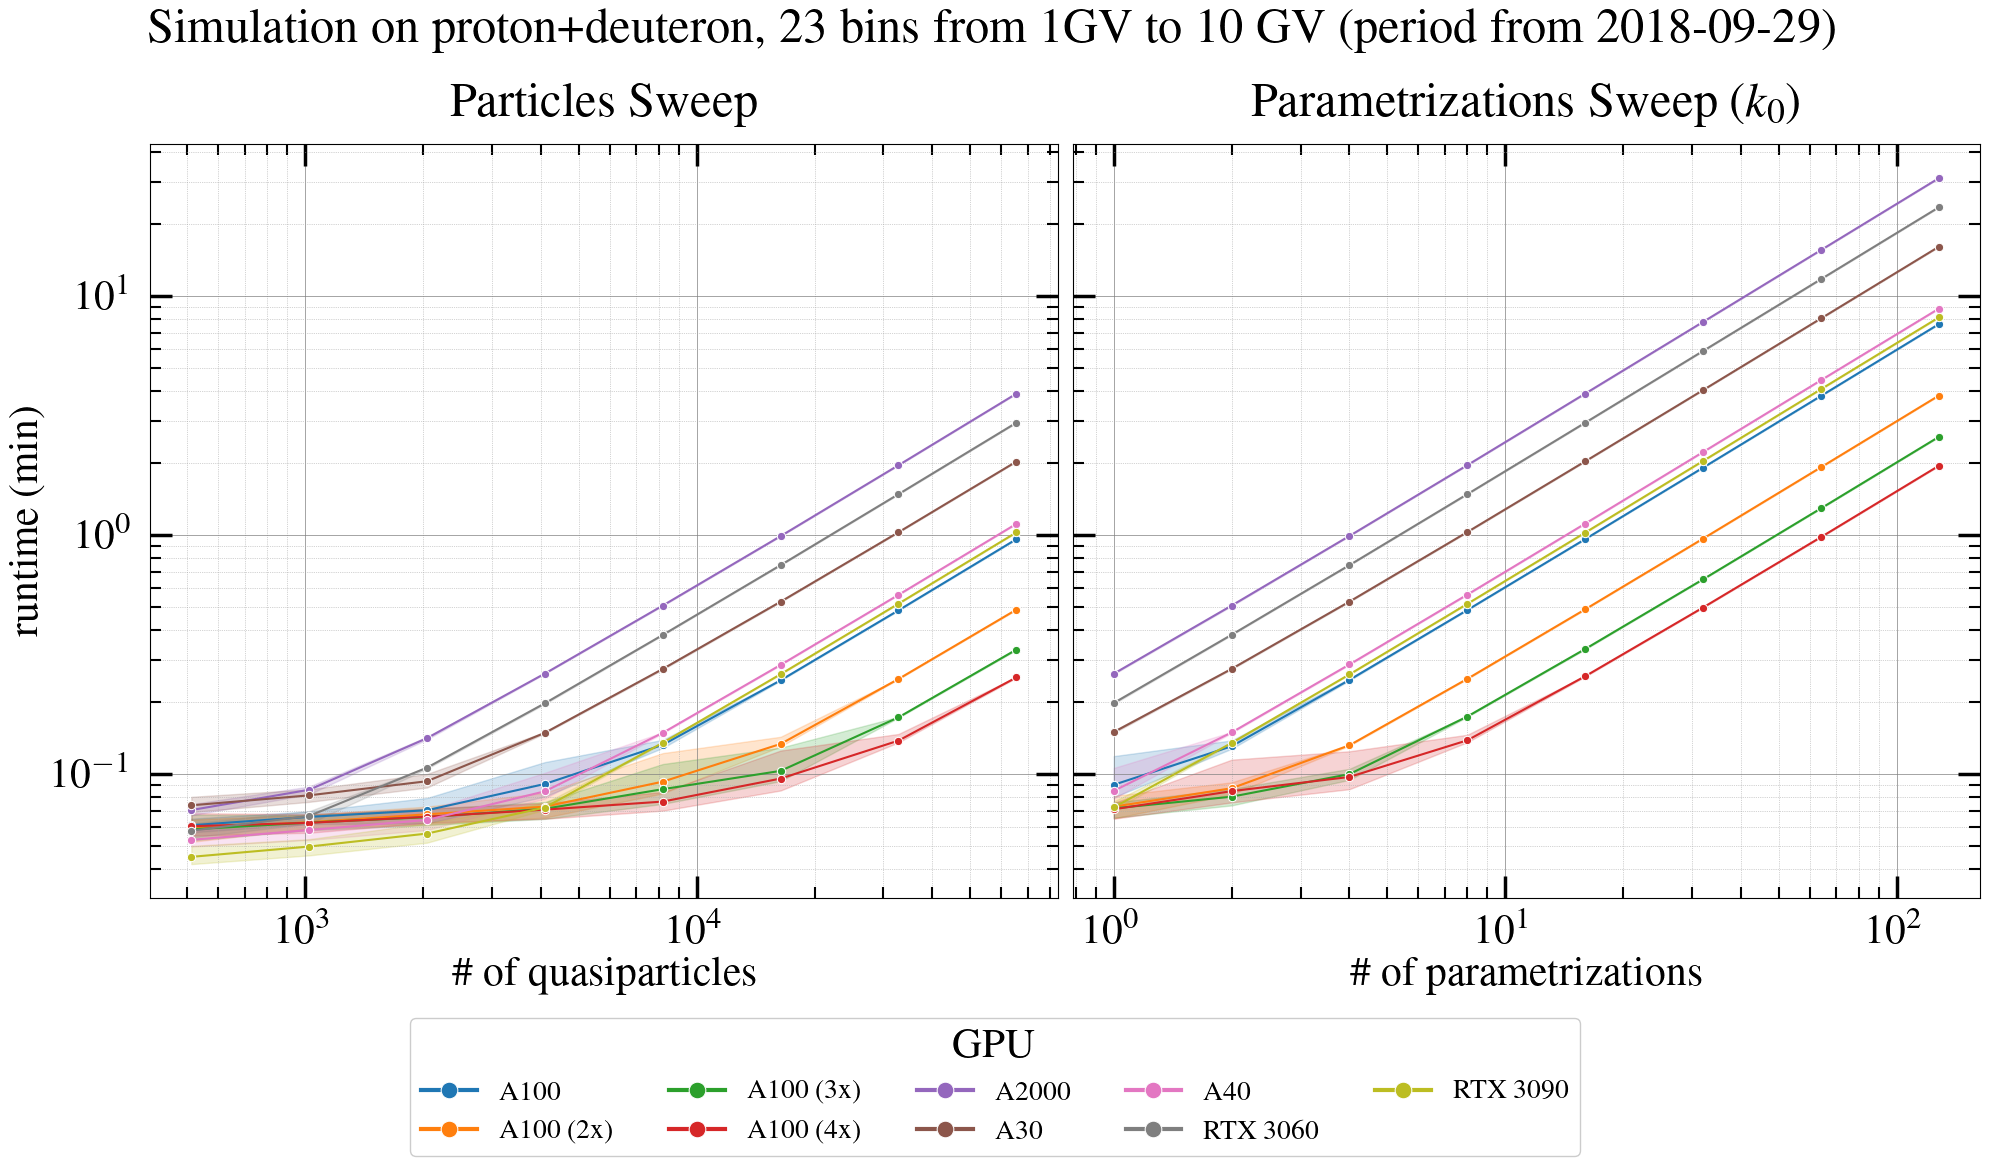

In [42]:
for date in df['date'].unique():
    plot_scale_vs_time_per_gpu("V8", date)
    save_plot(f'scale_vs_time_per_gpu_{date}')
    plt.show()

In [43]:
def plot_scale_vs_time_per_version(device):
    df_ = df.query(f'(device == "{device}")')
    fig, ax1, ax2 = make_pair_panel()
    fig.suptitle(f'Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='exetime',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax1,
    )
    ax1.set(title='Particles Sweep', xlabel=r'\# of quasiparticles', ylabel='runtime (min)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='exetime',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax2,
    )
    ax2.set(title='Parametrizations Sweep ($k_0$)', xlabel=r'\# of parametrizations', ylabel='runtime (min)')

    make_figure_legend(fig, (ax1, ax2), 'Version')

    return fig, ax1, ax2

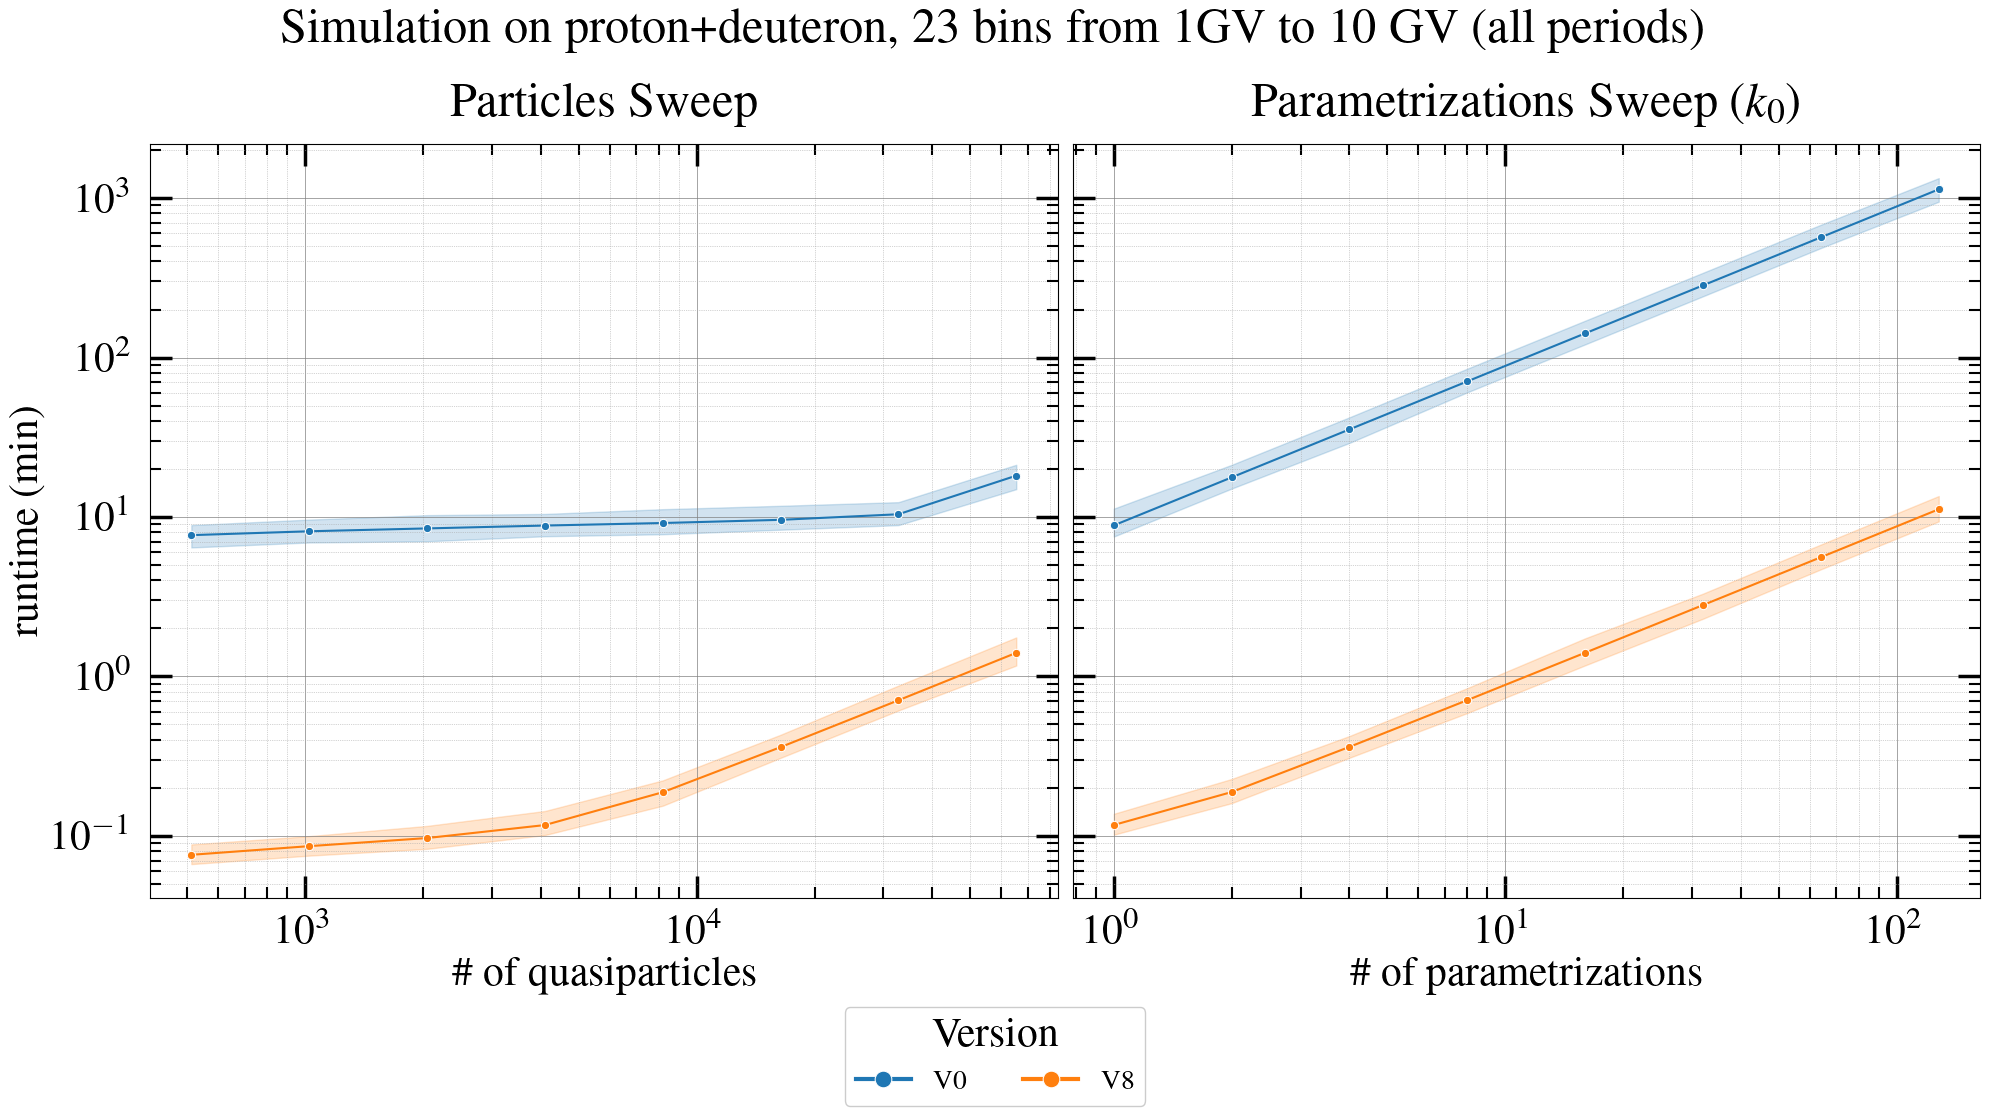

In [44]:
plot_scale_vs_time_per_version("A100")
save_plot('scale_vs_time_per_version')
plt.show()

In [45]:
def plot_scale_vs_speedup_per_date(device, versions):
    df_ = pd.merge(
        df.query(f'(device == "{device}") & (version == "{versions[0]}")'),
        df.query(f'(device == "{device}") & (version == "{versions[1]}")'),
        on=['date', 'seed', 'test', 'val', 'device'],
    )
    df_['ratio'] = df_['exetime_x'] / df_['exetime_y']
    fig, ax1, ax2 = make_pair_panel(sharey=False)
    fig.suptitle(f'Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('ci', 100),
        palette='muted',
        ax=ax1,
    )
    ax1.set(title='Particles Sweep', yscale='linear', xlabel=r'\# of quasiparticles', ylabel='speedup (x times)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='ratio',
        hue='date',
        marker='o',
        errorbar=('ci', 100),
        palette='muted',
        ax=ax2,
    )
    ax2.set(title='Parametrizations Sweep ($k_0$)', yscale='linear', xlabel=r'\# of parametrizations',
            ylabel='speedup (x times)')

    make_figure_legend(fig, (ax1, ax2), 'Date', map_labels=lambda x: format_int_to_date(x))

    return fig, ax1, ax2

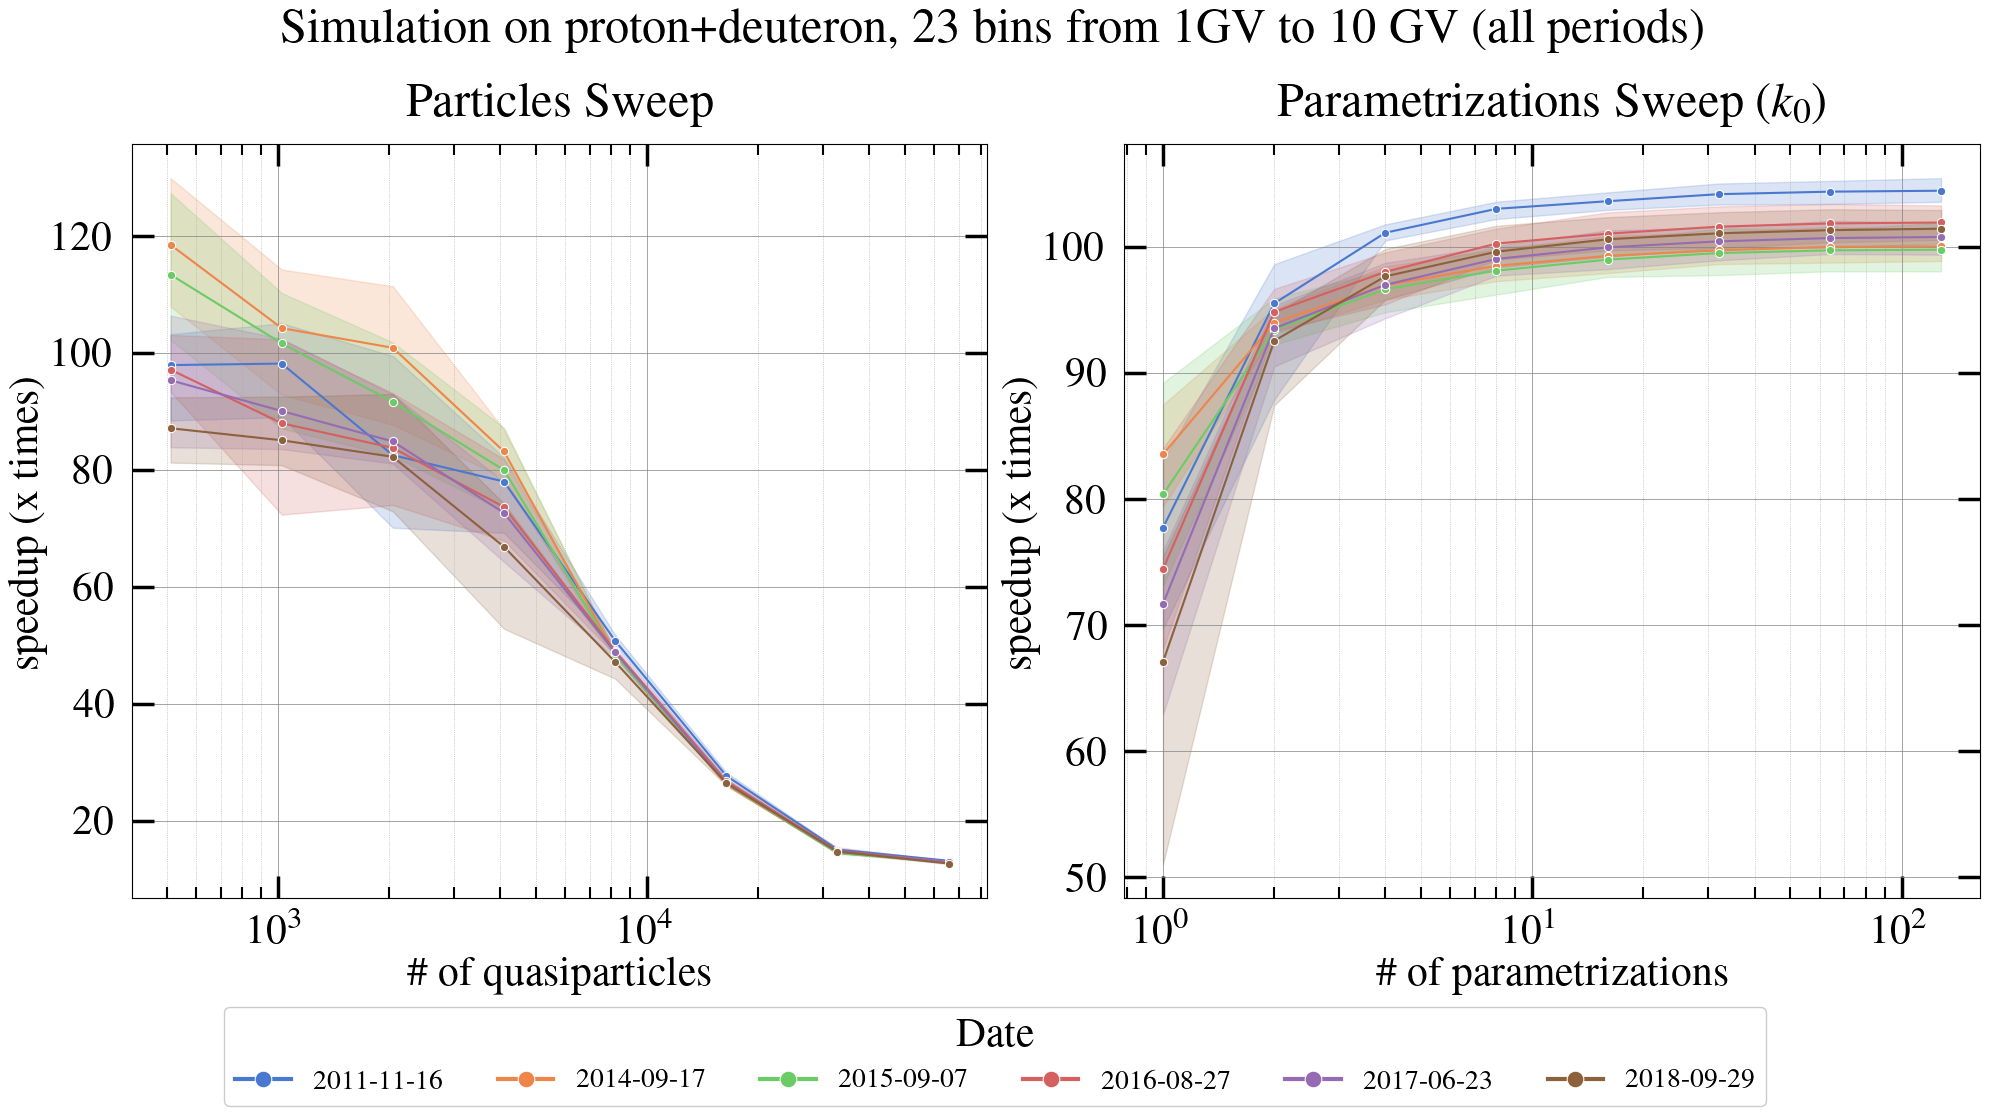

In [46]:
plot_scale_vs_speedup_per_date("A100", ("V0", "V8"))
save_plot('scale_vs_speedup_per_date')
plt.show()

In [47]:
def plot_scale_vs_energy_per_version(device):
    df_ = df.query(f'(device == "{device}")')
    fig, ax1, ax2 = make_pair_panel()
    fig.suptitle(f'Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='power_energy',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax1,
    )
    ax1.set(title='Particles Sweep', xlabel=r'\# of quasiparticles', ylabel='energy (Wh)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='power_energy',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax2,
    )
    ax2.set(title='Parametrizations Sweep ($k_0$)', xlabel=r'\# of parametrizations', ylabel='energy (Wh)')

    make_figure_legend(fig, (ax1, ax2), 'Version')

    return fig, ax1, ax2

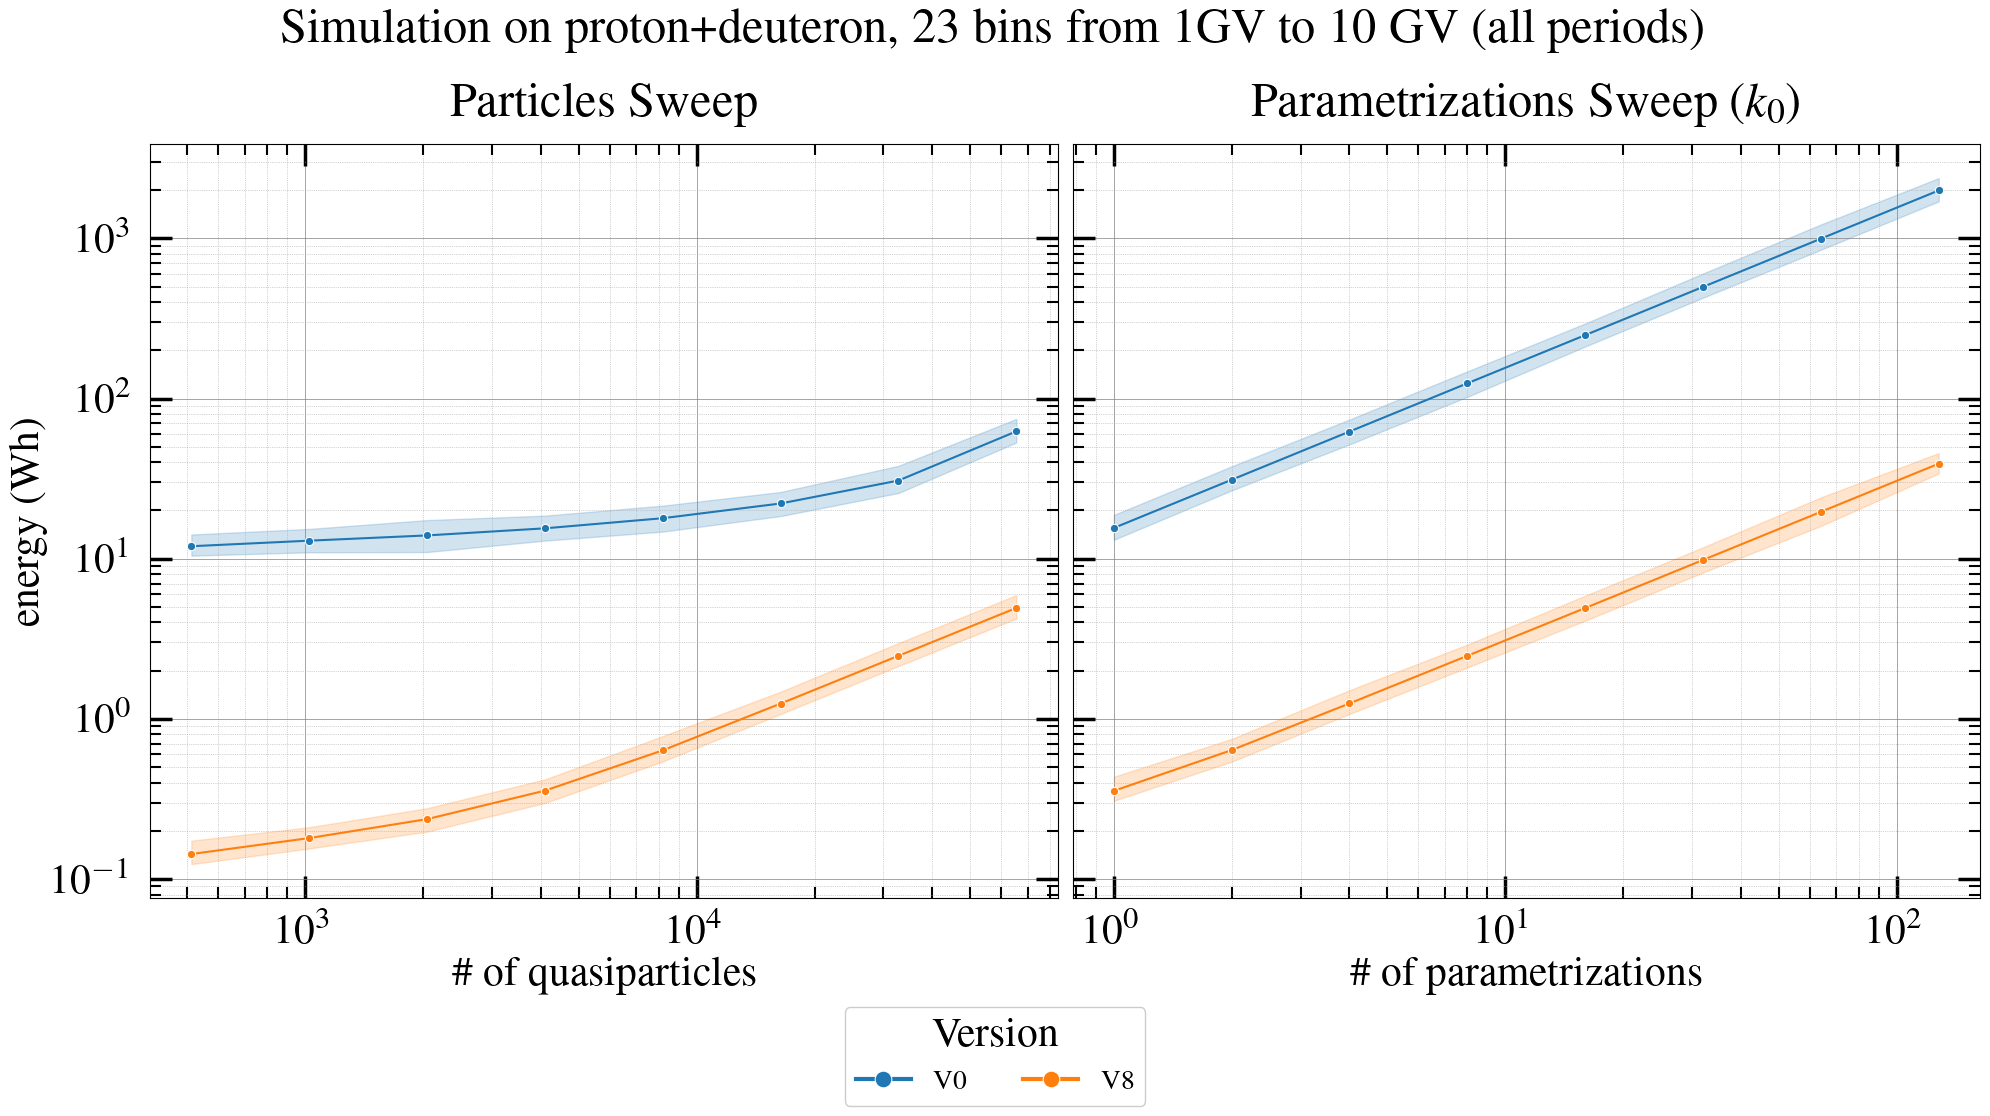

In [48]:
plot_scale_vs_energy_per_version("A100")
save_plot('scale_vs_energy_per_version')
plt.show()

In [49]:
def plot_scale_vs_power_per_version(device):
    df_ = df.query(f'(device == "{device}")')
    fig, ax1, ax2 = make_pair_panel()
    fig.suptitle(f'Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)

    sns.lineplot(
        data=df_.query('test == "part"'),
        x='val',
        y='power_inst',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax1,
    )
    ax1.set(title='Particles Sweep', xlabel=r'\# of quasiparticles', ylabel='power (W)')

    sns.lineplot(
        data=df_.query('test == "k0"'),
        x='val',
        y='power_inst',
        hue='version',
        marker='o',
        errorbar=('ci', 100),
        ax=ax2,
    )
    ax2.set(title='Parametrizations Sweep ($k_0$)', xlabel=r'\# of parametrizations', ylabel='power (W)')

    make_figure_legend(fig, (ax1, ax2), 'Version')

    return fig, ax1, ax2

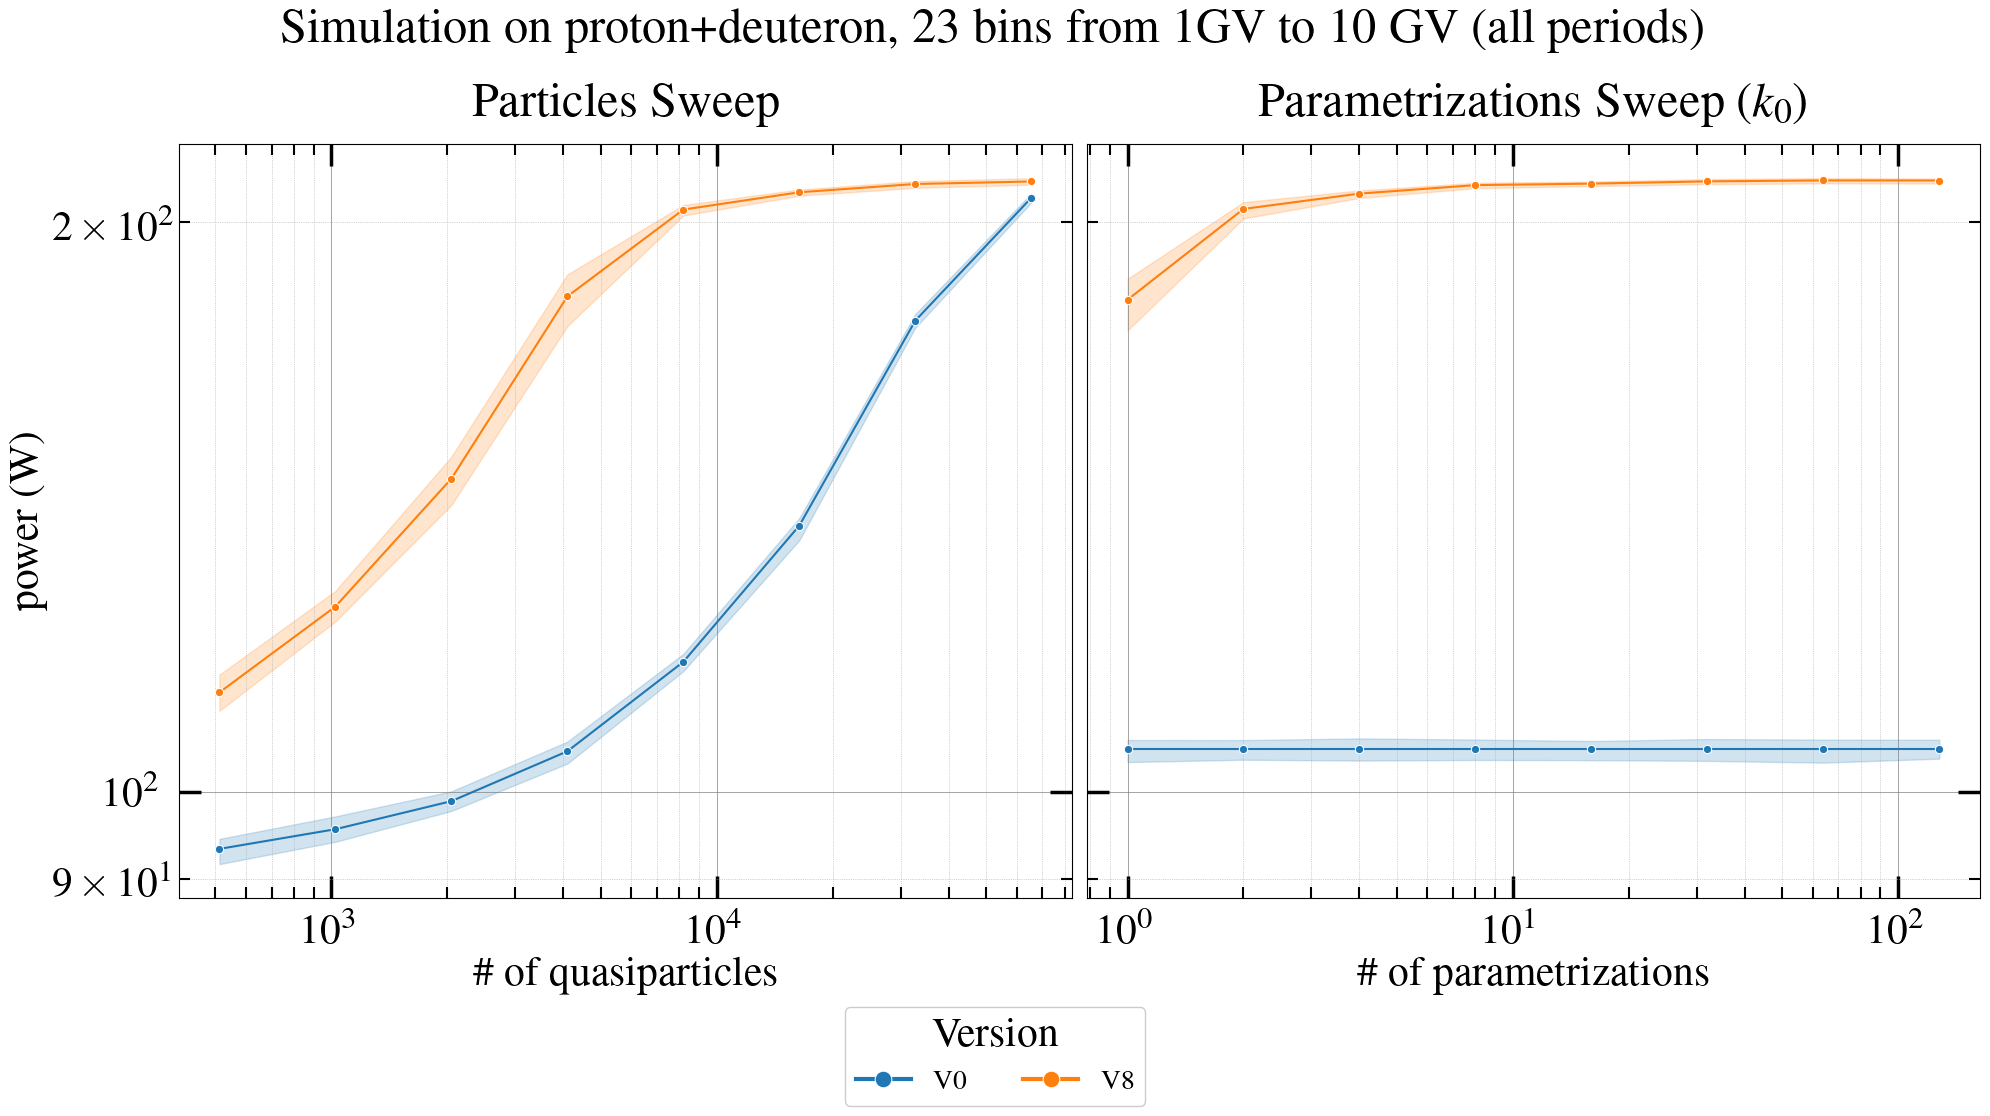

In [50]:
plot_scale_vs_power_per_version("A100")
save_plot('scale_vs_power_per_version')
plt.show()

In [51]:
def plot_device_vs_energy_per_date():
    fig, ax = plt.subplots(figsize=(20, 10), tight_layout=True)
    fig.suptitle('Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (128 parametrizations)', y=1)
    set_axis_fine_grid(ax, 'y')

    sns.barplot(
        data=df.query('(version == "V8") & (test == "k0") & (val == 128)'),
        x='device',
        y='power_energy',
        hue='date',
        errorbar=('ci', 100),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel=None, ylabel='energy (Wh)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax, ), 'Date', map_labels=lambda x: format_int_to_date(x))

    return fig, ax

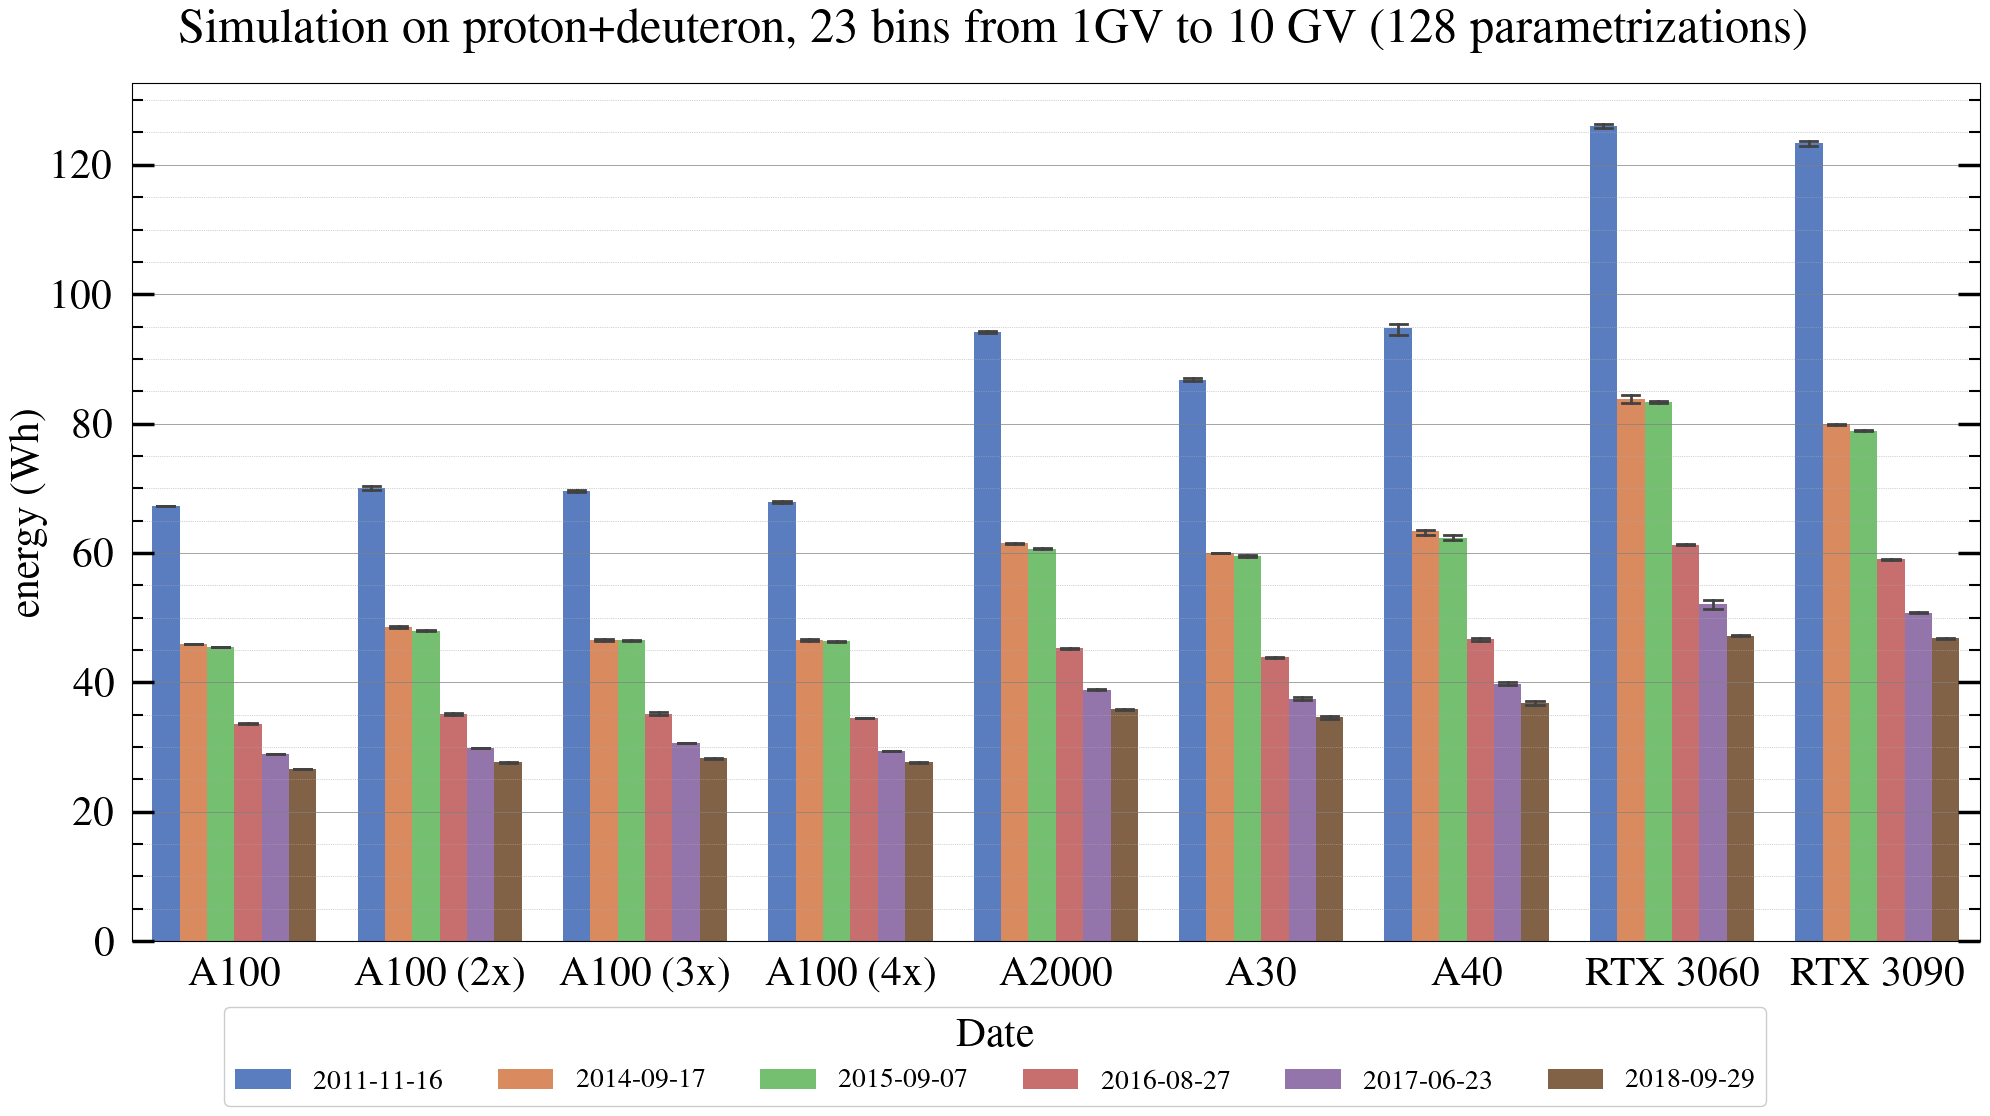

In [52]:
plot_device_vs_energy_per_date()
save_plot('device_vs_energy_per_date')
plt.show()

In [53]:
def plot_device_vs_power_per_param():
    fig, ax = plt.subplots(figsize=(20, 10), tight_layout=True)
    fig.suptitle('Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)
    set_axis_fine_grid(ax, 'y')
    sns.barplot(
        data=df.query('(version == "V8") & (test == "k0")'),
        x='device',
        y='power_inst',
        hue='val',
        errorbar=('ci', 100),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel=None, ylabel='power (W)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax, ), r'\# $k_0$')

    return fig, ax

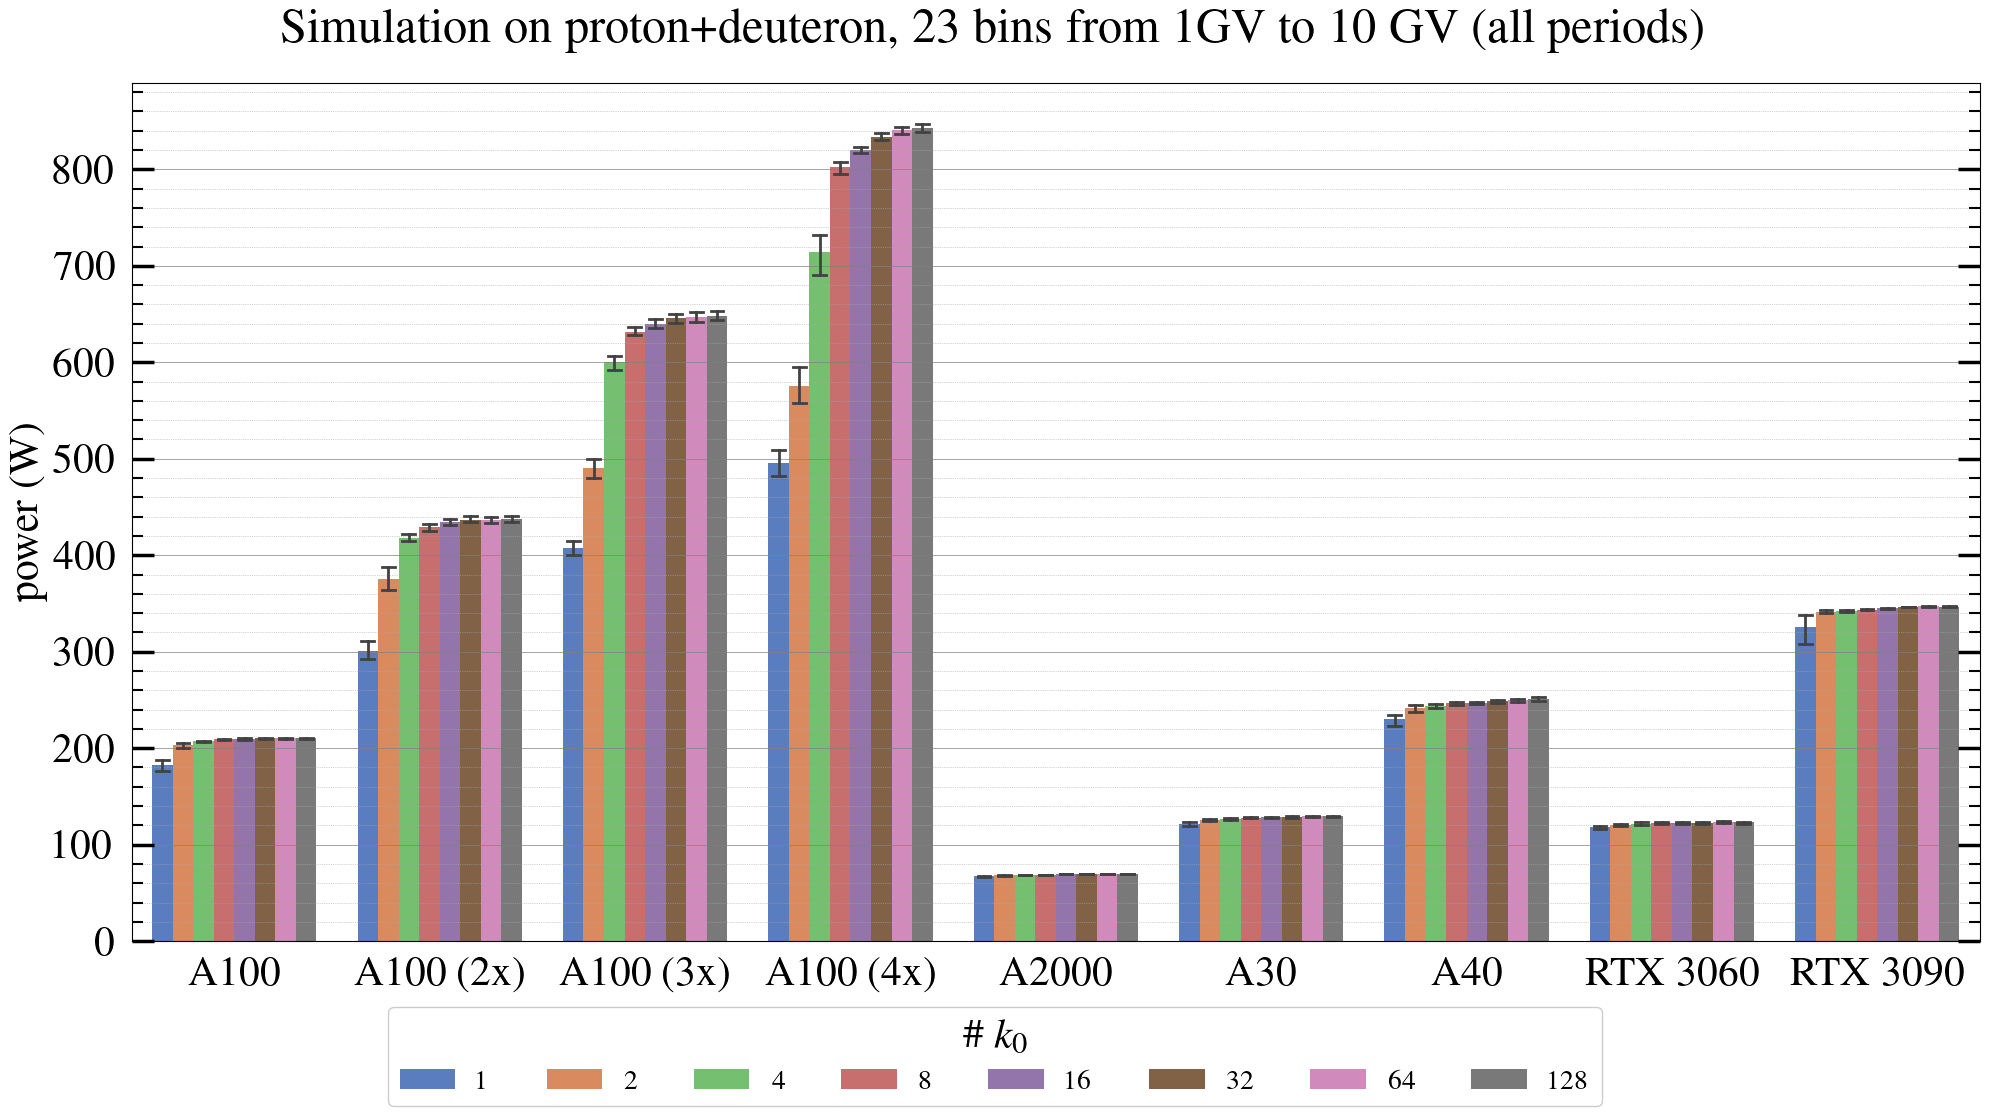

In [54]:
plot_device_vs_power_per_param()
save_plot('device_vs_power_per_param')
plt.show()

In [55]:
def plot_device_vs_power_per_part():
    fig, ax = plt.subplots(figsize=(20, 10), tight_layout=True)
    fig.suptitle('Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (all periods)', y=1)
    set_axis_fine_grid(ax, 'y')
    sns.barplot(
        data=df.query('(version == "V8") & (test == "part")'),
        x='device',
        y='power_inst',
        hue='val',
        errorbar=('ci', 100),
        capsize=.5,
        err_kws={'linewidth': 2},
        palette='muted',
        ax=ax,
    )
    ax.set(xlabel=None, ylabel='power (W)')
    ax.xaxis.set_ticks_position('none')

    make_figure_legend(fig, (ax, ), r'\# particles')

    return fig, ax

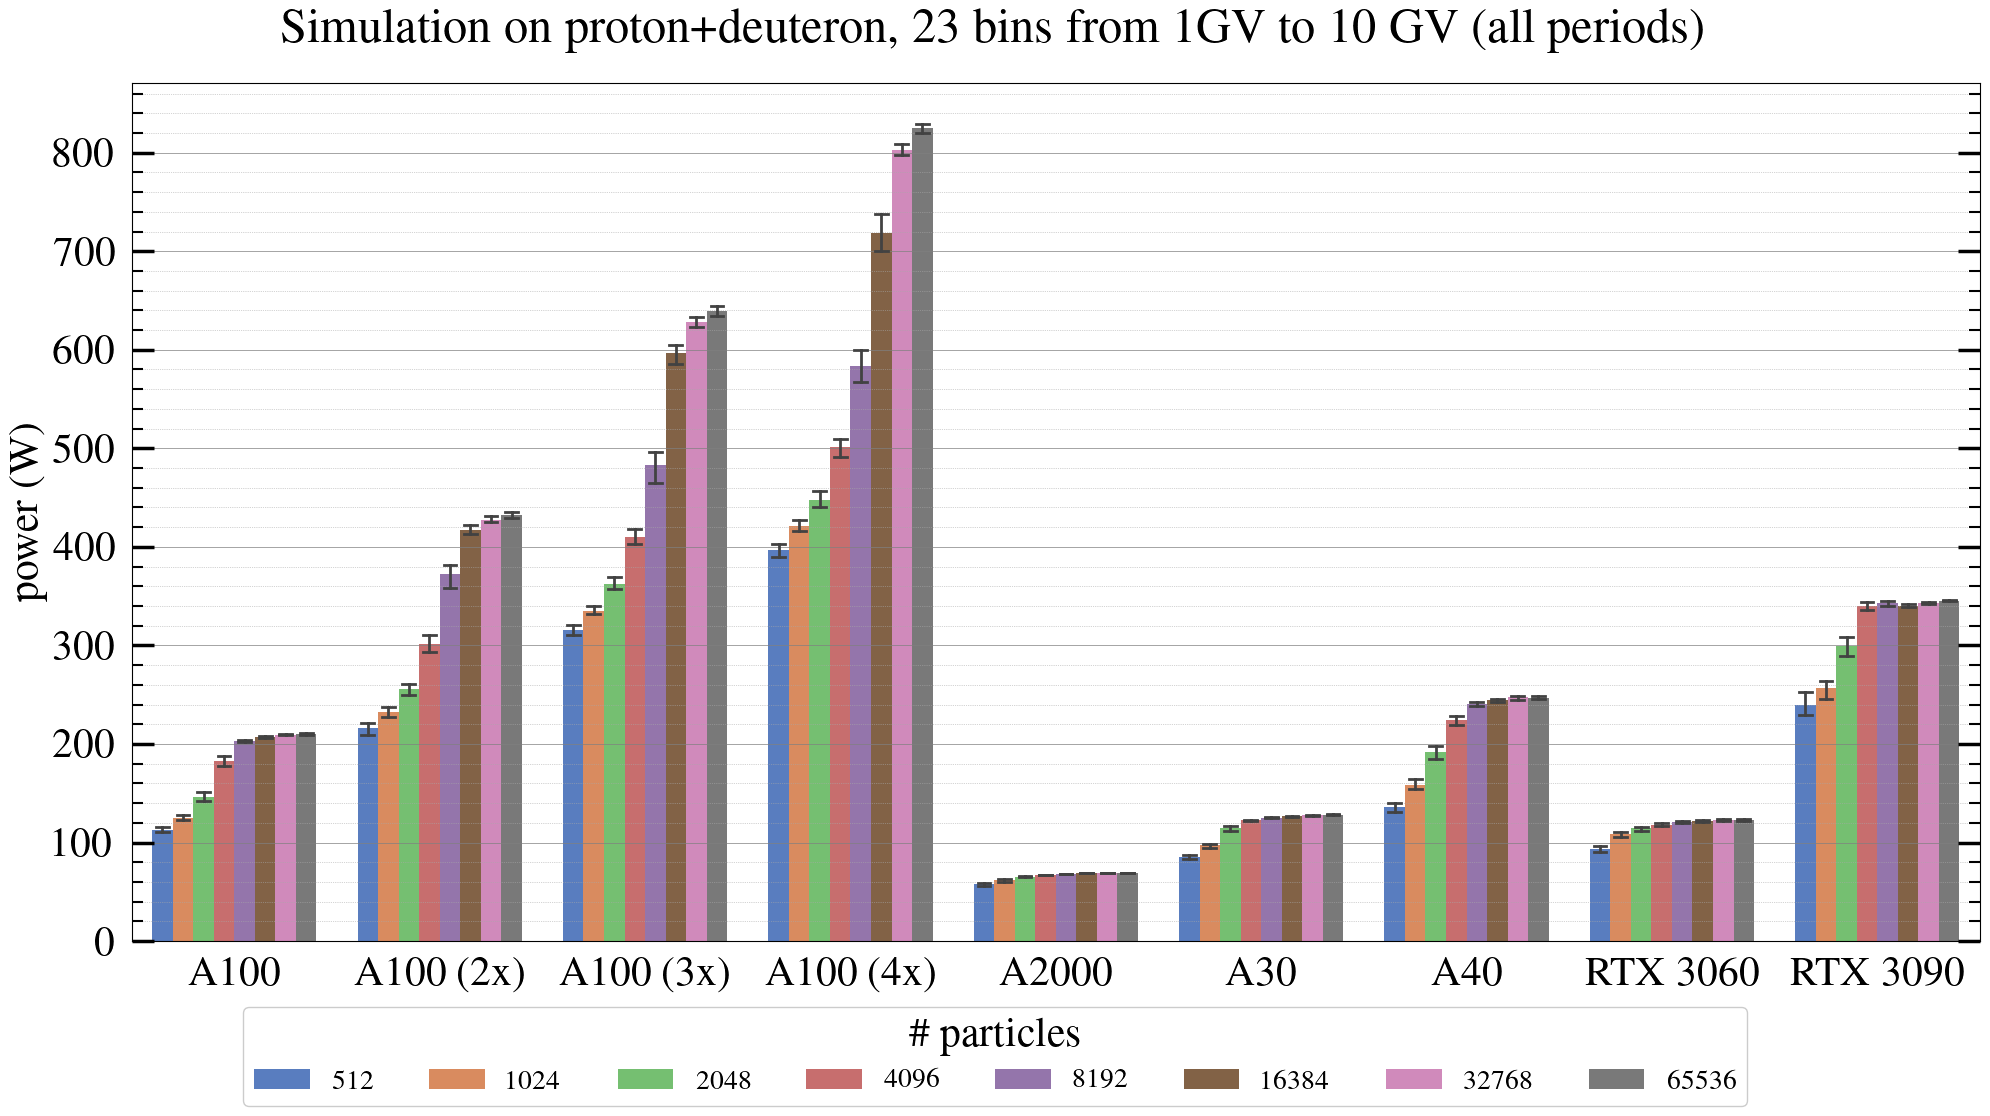

In [56]:
plot_device_vs_power_per_part()
save_plot('device_vs_power_per_part')
plt.show()